<a href="https://colab.research.google.com/github/SamShinwari/Advanced-AI-Bootcamp-2026/blob/main/Project_8_TF_IDF_(Term_Frequency_%E2%80%93_Inverse_Document_Frequency).ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# **Project 8: TF-IDF (Term Frequency – Inverse Document Frequency)**

## Objective

In this project, you'll learn how to convert text into **weighted numerical vectors** using **TF-IDF**.

Unlike **Bag of Words**, which only counts word occurrences, **TF-IDF assigns higher weights to important words and lower weights to very common words**.

It is one of the most popular feature extraction techniques in NLP and Machine Learning.
write this above code, in each markdown and code cell

---

# Why Do We Need TF-IDF?

Suppose we have the following documents:

```text
D1: Ukraine war begins

D2: Ukraine wins war

D3: Ukraine war continues

D4: Covid cases increasing
```

### Bag of Words

| Word      | D1 | D2 | D3 | D4 |
| --------- | -: | -: | -: | -: |
| Ukraine   |  1 |  1 |  1 |  0 |
| War       |  1 |  1 |  1 |  0 |
| Begins    |  1 |  0 |  0 |  0 |
| Wins      |  0 |  1 |  0 |  0 |
| Continues |  0 |  0 |  1 |  0 |
| Covid     |  0 |  0 |  0 |  1 |

Bag of Words treats **Ukraine** and **Begins** equally.

But **Ukraine** appears in almost every document, so it carries less unique information.

TF-IDF reduces the weight of common words and increases the weight of distinctive words.
write this above code, in each markdown and code cell

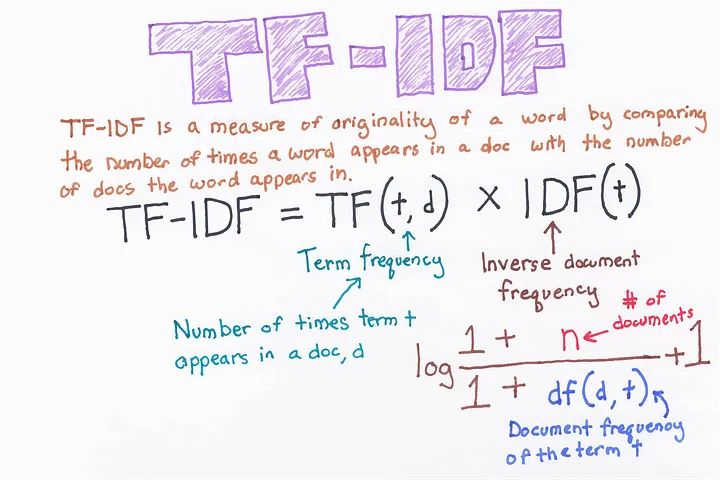

---

# Step 1: Import Libraries
write this above code, in each markdown and code cell

In [40]:
import nltk

Download the English model:

In [41]:
# Download required resources (run once)
nltk.download('punkt')
nltk.download('punkt_tab')
nltk.download('averaged_perceptron_tagger')

[nltk_data] Downloading package punkt to /root/nltk_data...
[nltk_data]   Package punkt is already up-to-date!
[nltk_data] Downloading package punkt_tab to /root/nltk_data...
[nltk_data]   Package punkt_tab is already up-to-date!
[nltk_data] Downloading package averaged_perceptron_tagger to
[nltk_data]     /root/nltk_data...
[nltk_data]   Package averaged_perceptron_tagger is already up-to-
[nltk_data]       date!


True

---

# Step 2: Import Libraries

In [42]:
import pandas as pd
import spacy
from google.colab import drive
from sklearn.feature_extraction.text import TfidfVectorizer
import matplotlib.pyplot as plt
import re
import nltk
from nltk.corpus import stopwords
from nltk.stem import WordNetLemmatizer
from google.colab import drive


In [43]:
drive.mount('/content/drive')

Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).


---

# Step 3: Load the English Model

In [44]:
nlp = spacy.load("en_core_web_sm")
# Download required resources (run once)
nltk.download('punkt')
nltk.download('punkt_tab')
nltk.download('averaged_perceptron_tagger')

[nltk_data] Downloading package punkt to /root/nltk_data...
[nltk_data]   Package punkt is already up-to-date!
[nltk_data] Downloading package punkt_tab to /root/nltk_data...
[nltk_data]   Package punkt_tab is already up-to-date!
[nltk_data] Downloading package averaged_perceptron_tagger to
[nltk_data]     /root/nltk_data...
[nltk_data]   Package averaged_perceptron_tagger is already up-to-
[nltk_data]       date!


True

---

# Step 4: Load Dataset

In [45]:
file_path = '/content/drive/MyDrive/Colab Notebooks/bbc_dataset.csv'
df = pd.read_csv(file_path)
df.head()

,title,pubDate,guid,link,description
0,Ukraine: Angry Zelensky vows to punish Russian...,"Mon, 07 Mar 2022 08:01:56 GMT",https://www.bbc.co.uk/news/world-europe-60638042,https://www.bbc.co.uk/news/world-europe-606380...,The Ukrainian president says the country will ...
1,War in Ukraine: Taking cover in a town under a...,"Sun, 06 Mar 2022 22:49:58 GMT",https://www.bbc.co.uk/news/world-europe-60641873,https://www.bbc.co.uk/news/world-europe-606418...,"Jeremy Bowen was on the frontline in Irpin, as..."
2,Ukraine war 'catastrophic for global food',"Mon, 07 Mar 2022 00:14:42 GMT",https://www.bbc.co.uk/news/business-60623941,https://www.bbc.co.uk/news/business-60623941?a...,One of the world's biggest fertiliser firms sa...
3,Manchester Arena bombing: Saffie Roussos's par...,"Mon, 07 Mar 2022 00:05:40 GMT",https://www.bbc.co.uk/news/uk-60579079,https://www.bbc.co.uk/news/uk-60579079?at_medi...,The parents of the Manchester Arena bombing's ...
4,Ukraine conflict: Oil price soars to highest l...,"Mon, 07 Mar 2022 08:15:53 GMT",https://www.bbc.co.uk/news/business-60642786,https://www.bbc.co.uk/news/business-60642786?a...,Consumers are feeling the impact of higher ene...


In [46]:
df = df.dropna(subset=["description"])
df = df.drop_duplicates(subset=["description"])
df = df.reset_index(drop=True)

In [47]:
df = df.drop(columns=['guid', 'link','pubDate'])
df.head()

,title,description
0,Ukraine: Angry Zelensky vows to punish Russian...,The Ukrainian president says the country will ...
1,War in Ukraine: Taking cover in a town under a...,"Jeremy Bowen was on the frontline in Irpin, as..."
2,Ukraine war 'catastrophic for global food',One of the world's biggest fertiliser firms sa...
3,Manchester Arena bombing: Saffie Roussos's par...,The parents of the Manchester Arena bombing's ...
4,Ukraine conflict: Oil price soars to highest l...,Consumers are feeling the impact of higher ene...


In [48]:

nltk.download('stopwords', quiet=True)
nltk.download('wordnet', quiet=True)


True

In [49]:

lemmatizer = WordNetLemmatizer()
stop_words = set(stopwords.words('english'))

def preprocess_text(text):
    if not isinstance(text, str):
        return ""
    # Convert to lowercase
    text = text.lower()
    # Remove punctuation and numbers
    text = re.sub(r'[^a-z\s]', '', text)
    # Tokenize
    words = text.split()
    # Remove stopwords and lemmatize
    words = [lemmatizer.lemmatize(word) for word in words if word not in stop_words]
    # Join words back into a string
    return ' '.join(words)

# Apply the preprocessing function to the 'description' column to create 'clean_text'
df['clean_text'] = df['description'].apply(preprocess_text)

print(df[['description', 'clean_text']].head())

                                         description  \
0  The Ukrainian president says the country will ...   
1  Jeremy Bowen was on the frontline in Irpin, as...   
2  One of the world's biggest fertiliser firms sa...   
3  The parents of the Manchester Arena bombing's ...   
4  Consumers are feeling the impact of higher ene...   

                                          clean_text  
0  ukrainian president say country forgive forget...  
1  jeremy bowen frontline irpin resident came rus...  
2  one world biggest fertiliser firm say conflict...  
3  parent manchester arena bombing youngest victi...  
4  consumer feeling impact higher energy cost fue...  


---

# Step 3: Display Sample Text
write this above code, in each markdown and code cell

In [50]:
print(df["clean_text"].head())


0    ukrainian president say country forgive forget...
1    jeremy bowen frontline irpin resident came rus...
2    one world biggest fertiliser firm say conflict...
3    parent manchester arena bombing youngest victi...
4    consumer feeling impact higher energy cost fue...
Name: clean_text, dtype: object


---

# Step 4: Create TF-IDF Vectorizer
write this above code, in each markdown and code cell

In [51]:
vectorizer = TfidfVectorizer()


---

# Step 5: Convert Text into TF-IDF Matrix
write this above code, in each markdown and code cell

In [52]:
X = vectorizer.fit_transform(df["clean_text"])

---

# Step 6: Matrix Shape
write this above code, in each markdown and code cell

In [53]:
print(X.shape)


(33124, 27887)


Example

```text
(2225, 6425)
```

Meaning

* 2225 news articles
* 6425 unique words
write this above code, in each markdown and code cell

---

# Step 7: Vocabulary
write this above code, in each markdown and code cell

In [54]:
print(vectorizer.get_feature_names_out())

['aa' 'aaliyah' 'aamir' ... 'zverevs' 'zwelithini' 'zwerner']


Example

```text
ability
able
abroad
accident
...
zelensky
zone
```
write this above code, in each markdown and code cell

---

# Step 8: Convert Matrix to DataFrame
write this above code, in each markdown and code cell

In [55]:
tfidf_df = pd.DataFrame(
    X.toarray(),
    columns=vectorizer.get_feature_names_out()
)

tfidf_df.head()

,aa,aaliyah,aamir,aanoch,aardman,aaron,aastha,ab,abandon,abandoned,...,zunino,zunyou,zurcher,zurich,zuu,zuwara,zverev,zverevs,zwelithini,zwerner
0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0
1,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0
2,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0
3,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0
4,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0


---

# Step 9: View TF-IDF Values
write this above code, in each markdown and code cell

In [56]:
print(tfidf_df.iloc[0].sort_values(ascending=False).head(15))


forgive          0.528703
forget           0.475335
civilian         0.362154
murder           0.326435
ukrainian        0.300060
country          0.271812
president        0.263926
say              0.152445
percussionist    0.000000
percival         0.000000
perceived        0.000000
perched          0.000000
perception       0.000000
percentage       0.000000
peregrine        0.000000
Name: 0, dtype: float64


Example

```text
zelensky      0.52

atrocity      0.48

punish        0.45

ukraine       0.31

russian       0.28
```

Notice that **zelensky** has a higher weight than **ukraine** because it appears in fewer documents.
write this above code, in each markdown and code cell

---

# Step 10: Vocabulary Size
write this above code, in each markdown and code cell

In [57]:
print("Vocabulary Size:",
      len(vectorizer.get_feature_names_out()))

Vocabulary Size: 27887


---

# Step 11: Top TF-IDF Words in One Document
write this above code, in each markdown and code cell

In [58]:
document = 0

scores = tfidf_df.iloc[document]

top_words = scores.sort_values(
    ascending=False
).head(10)

print(top_words)

forgive          0.528703
forget           0.475335
civilian         0.362154
murder           0.326435
ukrainian        0.300060
country          0.271812
president        0.263926
say              0.152445
percussionist    0.000000
percival         0.000000
Name: 0, dtype: float64


---

# Step 12: Top TF-IDF Words Across Dataset
write this above code, in each markdown and code cell

In [59]:
average_scores = tfidf_df.mean(axis=0)

top_words = average_scores.sort_values(
    ascending=False
).head(20)

print(top_words)


say        0.019408
year       0.009552
england    0.009292
world      0.009000
people     0.008719
bbc        0.008321
first      0.008042
new        0.008018
uk         0.007312
cup        0.007123
one        0.006441
two        0.006433
win        0.006237
league     0.006224
day        0.006013
police     0.005709
ukraine    0.005503
city       0.005302
former     0.005250
could      0.005216
dtype: float64


---

# Step 13: Limit Vocabulary
write this above code, in each markdown and code cell

In [60]:
vectorizer = TfidfVectorizer(
    max_features=1000
)

X = vectorizer.fit_transform(df["clean_text"])

print(X.shape)


(33124, 1000)


---

# Step 14: Remove Rare Words
write this above code, in each markdown and code cell

In [61]:
vectorizer = TfidfVectorizer(
    min_df=2
)

X = vectorizer.fit_transform(df["clean_text"])


---

# Step 15: Remove Very Common Words
write this above code, in each markdown and code cell

In [62]:
vectorizer = TfidfVectorizer(
    max_df=0.80
)

X = vectorizer.fit_transform(df["clean_text"])


---

# Step 16: Use Bigrams
write this above code, in each markdown and code cell

In [63]:
vectorizer = TfidfVectorizer(
    ngram_range=(1,2)
)

X = vectorizer.fit_transform(df["clean_text"])

print(X.shape)


(33124, 254969)


Vocabulary now includes

```text
ukraine

war

ukraine war

oil price

prime minister
```
write this above code, in each markdown and code cell

---

# Step 17: Visualize Important Words
write this above code, in each markdown and code cell

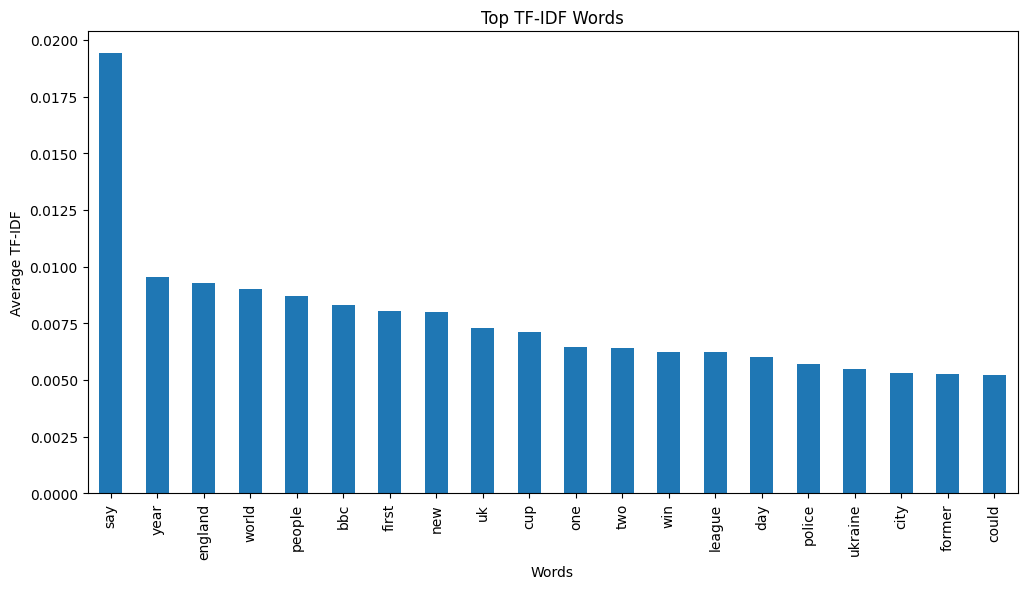

In [64]:
import matplotlib.pyplot as plt

average_scores = tfidf_df.mean(axis=0)

top20 = average_scores.sort_values(
    ascending=False
).head(20)

plt.figure(figsize=(12,6))

top20.plot(kind="bar")

plt.title("Top TF-IDF Words")

plt.xlabel("Words")

plt.ylabel("Average TF-IDF")

plt.show()


---

# Step 18: Find Important Words in Any Article
write this above code, in each markdown and code cell

In [65]:
article = 10

scores = tfidf_df.iloc[article]

important_words = scores.sort_values(
    ascending=False
).head(15)

print(important_words)


fled             0.415576
here             0.393172
know             0.346881
ukrainian        0.323186
million          0.322815
need             0.321897
war              0.299591
country          0.292762
day              0.254255
peregrine        0.000000
percentage       0.000000
percussionist    0.000000
pereira          0.000000
percival         0.000000
peres            0.000000
Name: 10, dtype: float64


---

# Step 19: Save TF-IDF Matrix
write this above code, in each markdown and code cell

In [68]:
# tfidf_df.to_csv(
#     "tfidf_matrix.csv",
#     index=False
# )

# print("Saved Successfully")



---

# Sample Output

## TF-IDF Matrix

| Document | ukraine |  war | covid | zelensky | atrocity |
| -------- | ------: | ---: | ----: | -------: | -------: |
| D1       |    0.31 | 0.00 |  0.00 |     0.52 |     0.48 |
| D2       |    0.42 | 0.36 |  0.00 |     0.00 |     0.00 |
| D3       |    0.00 | 0.00 |  0.59 |     0.00 |     0.00 |
write this above code, in each markdown and code cell

---

# Difference Between Bag of Words and TF-IDF

| Feature                    | Bag of Words | TF-IDF           |
| -------------------------- | ------------ | ---------------- |
| Counts words               | ✅            | ❌                |
| Uses weights               | ❌            | ✅                |
| Penalizes common words     | ❌            | ✅                |
| Highlights important words | ❌            | ✅                |
| Suitable for ML            | ✅            | ✅ (often better) |
write this above code, in each markdown and code cell

---

# Advantages of TF-IDF

* Reduces the importance of common words.
* Highlights informative terms.
* Often improves classification accuracy.
* Easy to compute and interpret.
* Widely used in search engines and information retrieval.
write this above code, in each markdown and code cell

---

# Limitations of TF-IDF

* Ignores word order.
* Cannot capture context or semantics.
* Produces sparse matrices.
* Does not understand synonyms or polysemy.
* Not suitable for capturing deep language meaning compared to Word2Vec or BERT.
write this above code, in each markdown and code cell

---

# Real-World Applications

* Search engines
* Document ranking
* News classification
* Spam detection
* Information retrieval
* Document similarity
* Topic modeling
* Recommendation systems
write this above code, in each markdown and code cell